In [ ]:
%pip install --quiet --break-system-packages pyodbc pandas sqlalchemy skikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Configure Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


In [4]:
# Connect to SQL Server Database
import pyodbc

server = 'DESKTOP-NGB83D4'
database = 'finance'
connection_string = f'Driver={{ODBC Driver 17 for SQL Server}};Server={server};Database={database};Trusted_Connection=yes;'

try:
    conn = pyodbc.connect(connection_string)
    print(f"✓ Database connection successful")
    print(f"  Server: {server}")
    print(f"  Database: {database}")
except Exception as e:
    print(f"✗ Connection error: {e}")
    conn = None

✓ Database connection successful
  Server: DESKTOP-NGB83D4
  Database: finance


In [5]:
# Load Data from SQL Server
if conn:
    try:
        df_investment = pd.read_sql_query('SELECT * FROM Finance_data', conn)
        df_original = pd.read_sql_query('SELECT * FROM Original_data', conn)
        conn.close()
        print(f"✓ Data loaded successfully")
        print(f"\nInvestment Dataset: {df_investment.shape[0]} records, {df_investment.shape[1]} features")
        print(f"Original Dataset: {df_original.shape[0]} records, {df_original.shape[1]} features")
    except Exception as e:
        print(f"✗ Data loading error: {e}")
        df_investment = None
        df_original = None
else:
    print("✗ Cannot load data: No database connection")
    df_investment = None
    df_original = None

✓ Data loaded successfully

Investment Dataset: 40 records, 24 features
Original Dataset: 40 records, 24 features


In [6]:
# Data Overview & Data Quality Assessment
print("="*80)
print("DATA OVERVIEW & QUALITY ASSESSMENT")
print("="*80)

print("\n1. Dataset Structure:")
print(f"   Shape: {df_investment.shape}")
print(f"\n2. Column Names & Data Types:")
print(df_investment.dtypes)

print(f"\n3. Missing Values Analysis:")
missing_data = df_investment.isnull().sum()
if missing_data.sum() == 0:
    print("   ✓ No missing values detected")
else:
    print(missing_data[missing_data > 0])

print(f"\n4. Statistical Summary:")
print(df_investment.describe())

DATA OVERVIEW & QUALITY ASSESSMENT

1. Dataset Structure:
   Shape: (40, 24)

2. Column Names & Data Types:
gender                                str
age                                 int64
Investment_Avenues                   bool
Mutual_Funds                        int64
Equity_Market                       int64
Debentures                          int64
Government_Bonds                    int64
Fixed_Deposits                      int64
PPF                                 int64
Gold                                int64
Stock_Marktet                        bool
Factor                                str
Objective                             str
Purpose                               str
Duration                              str
Invest_Monitor                        str
Expect                                str
Avenue                                str
What_are_your_savings_objectives      str
Reason_Equity                         str
Reason_Mutual                         str
Reason_Bon

In [7]:
# Demographic Analysis
print("\n" + "="*80)
print("DEMOGRAPHIC ANALYSIS")
print("="*80)

print("\n1. Gender Distribution:")
gender_dist = df_investment['gender'].value_counts()
print(gender_dist)
print(f"\nPercentage:")
print((gender_dist / len(df_investment) * 100).round(2))

print("\n2. Age Statistics:")
age_stats = df_investment['age'].describe()
print(age_stats)

print("\n3. Age Group Distribution:")
age_groups = pd.cut(df_investment['age'], bins=[0, 20, 30, 40, 50, 100], 
                     labels=['<20', '20-30', '30-40', '40-50', '50+'])
print(age_groups.value_counts().sort_index())


DEMOGRAPHIC ANALYSIS

1. Gender Distribution:
gender
Male      25
Female    15
Name: count, dtype: int64

Percentage:
gender
Male      62.5
Female    37.5
Name: count, dtype: float64

2. Age Statistics:
count    40.000000
mean     27.800000
std       3.560467
min      21.000000
25%      25.750000
50%      27.000000
75%      30.000000
max      35.000000
Name: age, dtype: float64

3. Age Group Distribution:
age
<20       0
20-30    31
30-40     9
40-50     0
50+       0
Name: count, dtype: int64


In [8]:
# Investment Participation Analysis
print("\n" + "="*80)
print("INVESTMENT PARTICIPATION ANALYSIS")
print("="*80)

print("\n1. Investment Avenues Participation:")
inv_avenues = df_investment['Investment_Avenues'].value_counts()
print(f"   Invested: {inv_avenues.get(True, 0)} ({inv_avenues.get(True, 0)/len(df_investment)*100:.1f}%)")
print(f"   Not Invested: {inv_avenues.get(False, 0)} ({inv_avenues.get(False, 0)/len(df_investment)*100:.1f}%)")

print("\n2. Stock Market Investment:")
stock_inv = df_investment['Stock_Marktet'].value_counts()
print(f"   Invested: {stock_inv.get(True, 0)} ({stock_inv.get(True, 0)/len(df_investment)*100:.1f}%)")
print(f"   Not Invested: {stock_inv.get(False, 0)} ({stock_inv.get(False, 0)/len(df_investment)*100:.1f}%)")


INVESTMENT PARTICIPATION ANALYSIS

1. Investment Avenues Participation:
   Invested: 37 (92.5%)
   Not Invested: 3 (7.5%)

2. Stock Market Investment:
   Invested: 35 (87.5%)
   Not Invested: 5 (12.5%)


In [9]:
# Investment Avenue Preferences Ranking
print("\n" + "="*80)
print("INVESTMENT AVENUE PREFERENCES RANKING")
print("="*80)

avenues = ['Mutual_Funds', 'Equity_Market', 'Debentures', 'Government_Bonds', 
           'Fixed_Deposits', 'PPF', 'Gold']
ranking_df = df_investment[avenues].copy()

print("\n1. Average Ranking by Investment Avenue (Lower = Higher Priority):")
avg_rank = ranking_df.mean().sort_values()
for i, (avenue, rank) in enumerate(avg_rank.items(), 1):
    print(f"   {i}. {avenue:20s}: {rank:.2f}")

print("\n2. First Choice (Rank = 1) Distribution:")
first_choice = {avenue: (ranking_df[avenue] == 1).sum() for avenue in avenues}
for avenue, count in sorted(first_choice.items(), key=lambda x: x[1], reverse=True):
    print(f"   {avenue:20s}: {count} customers ({count/len(ranking_df)*100:.1f}%)")


INVESTMENT AVENUE PREFERENCES RANKING

1. Average Ranking by Investment Avenue (Lower = Higher Priority):
   1. PPF                 : 2.02
   2. Mutual_Funds        : 2.55
   3. Equity_Market       : 3.48
   4. Fixed_Deposits      : 3.58
   5. Government_Bonds    : 4.65
   6. Debentures          : 5.75
   7. Gold                : 5.97

2. First Choice (Rank = 1) Distribution:
   PPF                 : 24 customers (60.0%)
   Fixed_Deposits      : 8 customers (20.0%)
   Mutual_Funds        : 4 customers (10.0%)
   Equity_Market       : 2 customers (5.0%)
   Debentures          : 1 customers (2.5%)
   Government_Bonds    : 1 customers (2.5%)
   Gold                : 0 customers (0.0%)


In [10]:
# Investment Characteristics Analysis
print("\n" + "="*80)
print("INVESTMENT CHARACTERISTICS ANALYSIS")
print("="*80)

characteristics = {
    'Factor': 'Key Factors Considered',
    'Objective': 'Investment Objective',
    'Purpose': 'Investment Purpose',
    'Duration': 'Investment Horizon',
    'Invest_Monitor': 'Monitoring Frequency',
    'Expect': 'Expected Returns',
    'Avenue': 'Primary Investment Avenue',
    'What_are_your_savings_objectives': 'Savings Objectives',
    'Source': 'Information Source'
}

for col, label in characteristics.items():
    if col in df_investment.columns:
        print(f"\n{label}:")
        dist = df_investment[col].value_counts().head(6)
        for value, count in dist.items():
            pct = count / len(df_investment) * 100
            print(f"   • {value:35s}: {count:3d} ({pct:5.1f}%)")


INVESTMENT CHARACTERISTICS ANALYSIS

Key Factors Considered:
   • Returns                            :  25 ( 62.5%)
   • Risk                               :  14 ( 35.0%)
   • Locking Period                     :   1 (  2.5%)

Investment Objective:
   • Capital Appreciation               :  26 ( 65.0%)
   • Growth                             :  11 ( 27.5%)
   • Income                             :   3 (  7.5%)

Investment Purpose:
   • Wealth Creation                    :  32 ( 80.0%)
   • Savings for Future                 :   6 ( 15.0%)
   • Returns                            :   2 (  5.0%)

Investment Horizon:
   • 3-5 years                          :  19 ( 47.5%)
   • 1-3 years                          :  18 ( 45.0%)
   • Less than 1 year                   :   2 (  5.0%)
   • More than 5 years                  :   1 (  2.5%)

Monitoring Frequency:
   • Monthly                            :  29 ( 72.5%)
   • Weekly                             :   7 ( 17.5%)
   • Daily               

In [11]:
# Investment Reasons Analysis
print("\n" + "="*80)
print("INVESTMENT REASONS ANALYSIS")
print("="*80)

reasons = {
    'Reason_Equity': 'Reasons for Stock Market Investment',
    'Reason_Mutual': 'Reasons for Mutual Fund Investment',
    'Reason_Bonds': 'Reasons for Government Bond Investment',
    'Reason_FD': 'Reasons for Fixed Deposit Investment'
}

for col, label in reasons.items():
    if col in df_investment.columns:
        print(f"\n{label}:")
        dist = df_investment[col].value_counts().head(5)
        for value, count in dist.items():
            if pd.notna(value):
                pct = count / len(df_investment) * 100
                print(f"   • {value:30s}: {count:3d} ({pct:5.1f}%)")


INVESTMENT REASONS ANALYSIS

Reasons for Stock Market Investment:
   • Capital Appreciation          :  30 ( 75.0%)
   • Dividend                      :   8 ( 20.0%)
   • Liquidity                     :   2 (  5.0%)

Reasons for Mutual Fund Investment:
   • Better Returns                :  24 ( 60.0%)
   • Fund Diversification          :  13 ( 32.5%)
   • Tax Benefits                  :   3 (  7.5%)

Reasons for Government Bond Investment:
   • Assured Returns               :  26 ( 65.0%)
   • Safe Investment               :  13 ( 32.5%)
   • Tax Incentives                :   1 (  2.5%)

Reasons for Fixed Deposit Investment:
   • Risk Free                     :  19 ( 47.5%)
   • Fixed Returns                 :  18 ( 45.0%)
   • High Interest Rates           :   3 (  7.5%)


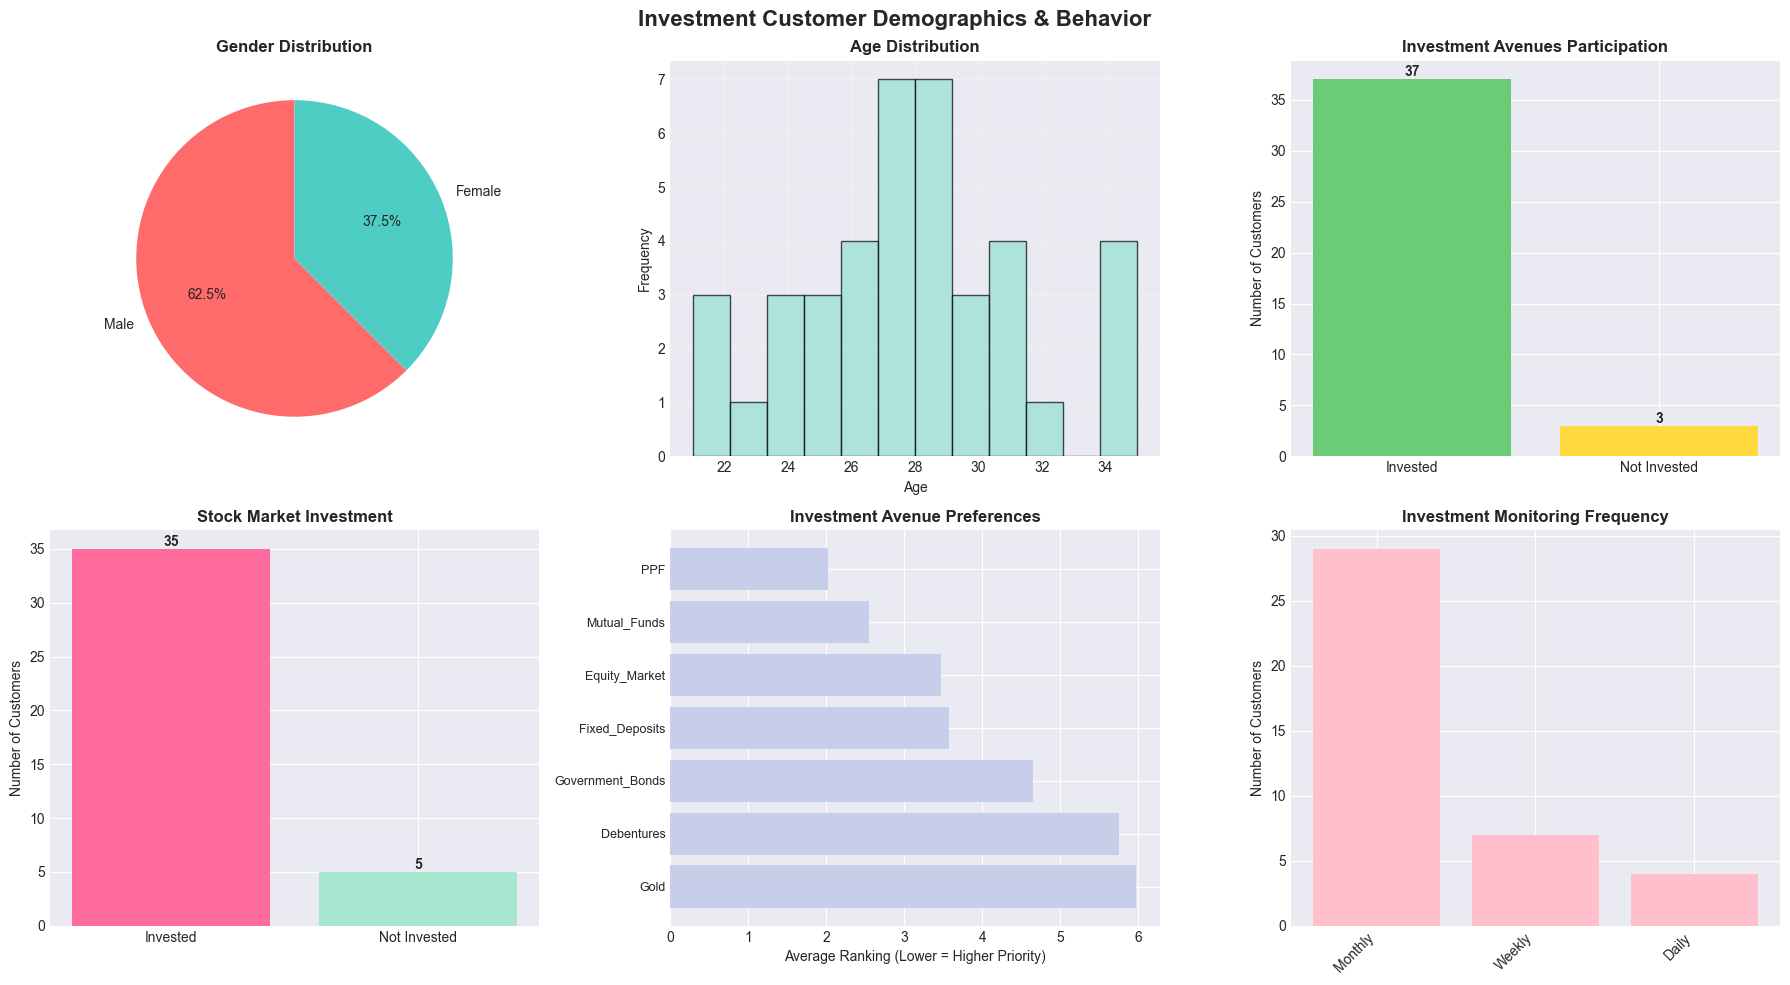

✓ Visualization completed


In [12]:
# Comprehensive Data Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Investment Customer Demographics & Behavior', fontsize=16, fontweight='bold')

# 1. Gender Distribution
gender_data = df_investment['gender'].value_counts()
axes[0, 0].pie(gender_data.values, labels=gender_data.index, autopct='%1.1f%%', 
               colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[0, 0].set_title('Gender Distribution', fontweight='bold')

# 2. Age Distribution
axes[0, 1].hist(df_investment['age'], bins=12, color='#95E1D3', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Age Distribution', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Investment Participation
inv_data = df_investment['Investment_Avenues'].value_counts()
bars = axes[0, 2].bar(['Invested', 'Not Invested'], 
                      [inv_data.get(True, 0), inv_data.get(False, 0)],
                      color=['#6BCB77', '#FFD93D'])
axes[0, 2].set_title('Investment Avenues Participation', fontweight='bold')
axes[0, 2].set_ylabel('Number of Customers')
for bar in bars:
    height = bar.get_height()
    axes[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# 4. Stock Market Investment
stock_data = df_investment['Stock_Marktet'].value_counts()
bars = axes[1, 0].bar(['Invested', 'Not Invested'],
                      [stock_data.get(True, 0), stock_data.get(False, 0)],
                      color=['#FF6B9D', '#A8E6CF'])
axes[1, 0].set_title('Stock Market Investment', fontweight='bold')
axes[1, 0].set_ylabel('Number of Customers')
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# 5. Investment Avenue Ranking
avenues = ['Mutual_Funds', 'Equity_Market', 'Debentures', 'Government_Bonds', 
           'Fixed_Deposits', 'PPF', 'Gold']
ranking_df = df_investment[avenues]
avg_rank = ranking_df.mean().sort_values()
axes[1, 1].barh(range(len(avg_rank)), avg_rank.values, color='#C7CEEA')
axes[1, 1].set_yticks(range(len(avg_rank)))
axes[1, 1].set_yticklabels(avg_rank.index, fontsize=9)
axes[1, 1].set_xlabel('Average Ranking (Lower = Higher Priority)')
axes[1, 1].set_title('Investment Avenue Preferences', fontweight='bold')
axes[1, 1].invert_yaxis()

# 6. Monitoring Frequency
if 'Invest_Monitor' in df_investment.columns:
    monitor_data = df_investment['Invest_Monitor'].value_counts()
    axes[1, 2].bar(range(len(monitor_data)), monitor_data.values, color='#FFC0CB')
    axes[1, 2].set_xticks(range(len(monitor_data)))
    axes[1, 2].set_xticklabels(monitor_data.index, rotation=45, ha='right')
    axes[1, 2].set_ylabel('Number of Customers')
    axes[1, 2].set_title('Investment Monitoring Frequency', fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ Visualization completed")

In [13]:
# Feature Engineering for Churn Prediction
print("="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Create a working dataframe
df_model = df_investment.copy()

# Define Churn: Low engagement indicators
print("\n1. Creating Churn Target Variable...")

# Churn criteria: 
#   - Did NOT invest in stock market AND
#   - Did NOT invest in investment avenues AND
#   - Not monitoring investments frequently
df_model['is_churn_risk'] = (
    (df_model['Stock_Marktet'] == False) & 
    (df_model['Investment_Avenues'] == False) |
    ((df_model['Invest_Monitor'] == 'Less Frequently') if 'Invest_Monitor' in df_model.columns else False)
).astype(int)

# Alternative: Low investment diversity (invested in only 1-2 avenues)
avenues_cols = ['Mutual_Funds', 'Equity_Market', 'Debentures', 'Government_Bonds', 
                'Fixed_Deposits', 'PPF', 'Gold']
df_model['investment_count'] = (df_model[avenues_cols] <= 5).sum(axis=1)
df_model['low_diversity'] = (df_model['investment_count'] <= 2).astype(int)

# Engagement score (higher score = higher engagement)
df_model['engagement_score'] = (
    (df_model['Stock_Marktet'].astype(int) * 2) +  # Stock market investment
    (df_model['Investment_Avenues'].astype(int) * 2) +  # Investment avenues
    (1 if 'Invest_Monitor' in df_model.columns and df_model['Invest_Monitor'].isin(['Daily', 'Weekly', 'Monthly']).sum() > 0 else 0)
)

print(f"   • Churn Risk Customers: {df_model['is_churn_risk'].sum()} ({df_model['is_churn_risk'].mean()*100:.1f}%)")
print(f"   • Low Investment Diversity: {df_model['low_diversity'].sum()} ({df_model['low_diversity'].mean()*100:.1f}%)")
print(f"   • Average Engagement Score: {df_model['engagement_score'].mean():.2f}")

FEATURE ENGINEERING

1. Creating Churn Target Variable...
   • Churn Risk Customers: 3 (7.5%)
   • Low Investment Diversity: 0 (0.0%)
   • Average Engagement Score: 4.60


In [14]:
# Data Preparation for Machine Learning Model
print("\n2. Preparing Features for Model Training...")

# Create feature set
features_to_encode = ['gender', 'Factor', 'Objective', 'Purpose', 'Duration', 
                      'Invest_Monitor', 'Expect', 'Avenue', 'Source']

df_encoded = df_model.copy()

# Encode categorical variables
label_encoders = {}
for col in features_to_encode:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le

# Select features for modeling
feature_cols = (
    ['age'] + 
    [col + '_encoded' for col in features_to_encode if col in df_encoded.columns] +
    ['investment_count', 'engagement_score']
)

X = df_encoded[feature_cols].fillna(df_encoded[feature_cols].mean())
y = df_encoded['is_churn_risk']

print(f"   • Feature Set: {X.shape[1]} features")
print(f"   • Sample Size: {X.shape[0]} records")
print(f"   • Target Distribution: {y.sum()} churn risk (positive class)")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                      random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n   ✓ Training Set: {X_train.shape[0]} records")
print(f"   ✓ Test Set: {X_test.shape[0]} records")
print(f"   ✓ Features Scaled")


2. Preparing Features for Model Training...
   • Feature Set: 12 features
   • Sample Size: 40 records
   • Target Distribution: 3 churn risk (positive class)

   ✓ Training Set: 28 records
   ✓ Test Set: 12 records
   ✓ Features Scaled


In [15]:
# Train Machine Learning Models
print("\n" + "="*80)
print("MODEL TRAINING & COMPARISON")
print("="*80)

# Model 1: Logistic Regression
print("\n1. Logistic Regression Model:")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_pred_proba)
print(f"   • AUC-ROC Score: {lr_auc:.4f}")

# Model 2: Random Forest
print("\n2. Random Forest Classifier:")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_pred_proba)
print(f"   • AUC-ROC Score: {rf_auc:.4f}")

# Select best model
if rf_auc >= lr_auc:
    best_model = rf_model
    best_pred = rf_pred
    best_pred_proba = rf_pred_proba
    best_auc = rf_auc
    best_model_name = "Random Forest"
else:
    best_model = lr_model
    best_pred = lr_pred
    best_pred_proba = lr_pred_proba
    best_auc = lr_auc
    best_model_name = "Logistic Regression"

print(f"\n✓ Best Model: {best_model_name} (AUC: {best_auc:.4f})")


MODEL TRAINING & COMPARISON

1. Logistic Regression Model:
   • AUC-ROC Score: 1.0000

2. Random Forest Classifier:
   • AUC-ROC Score: 1.0000

✓ Best Model: Random Forest (AUC: 1.0000)


In [16]:
# Model Evaluation & Performance Metrics
print("\n" + "="*80)
print("MODEL EVALUATION METRICS")
print("="*80)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, best_pred)
precision = precision_score(y_test, best_pred, zero_division=0)
recall = recall_score(y_test, best_pred, zero_division=0)
f1 = f1_score(y_test, best_pred, zero_division=0)

print(f"\n{best_model_name} Performance:")
print(f"   • Accuracy:  {accuracy:.4f}")
print(f"   • Precision: {precision:.4f}")
print(f"   • Recall:    {recall:.4f}")
print(f"   • F1-Score:  {f1:.4f}")
print(f"   • AUC-ROC:   {best_auc:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, best_pred, 
                          target_names=['No Churn Risk', 'Churn Risk'],
                          zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
print(f"\nConfusion Matrix:")
print(f"   True Negatives:  {cm[0, 0]}")
print(f"   False Positives: {cm[0, 1]}")
print(f"   False Negatives: {cm[1, 0]}")
print(f"   True Positives:  {cm[1, 1]}")


MODEL EVALUATION METRICS

Random Forest Performance:
   • Accuracy:  0.9167
   • Precision: 0.0000
   • Recall:    0.0000
   • F1-Score:  0.0000
   • AUC-ROC:   1.0000

Classification Report:
               precision    recall  f1-score   support

No Churn Risk       0.92      1.00      0.96        11
   Churn Risk       0.00      0.00      0.00         1

     accuracy                           0.92        12
    macro avg       0.46      0.50      0.48        12
 weighted avg       0.84      0.92      0.88        12


Confusion Matrix:
   True Negatives:  11
   False Positives: 0
   False Negatives: 1
   True Positives:  0


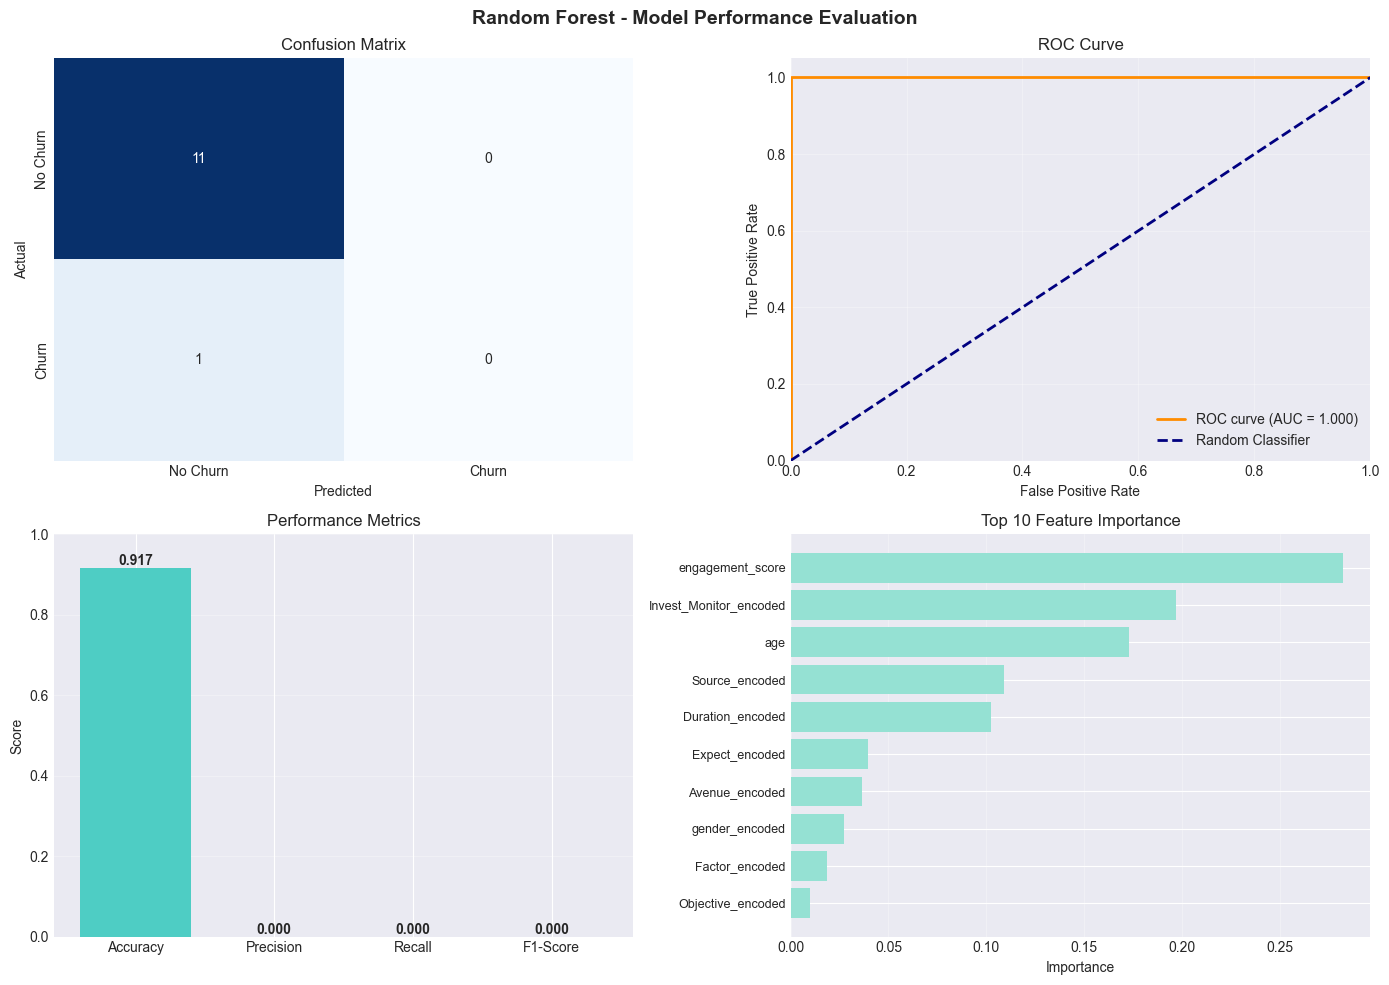

✓ Model visualization completed


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{best_model_name} - Model Performance Evaluation', fontsize=14, fontweight='bold')

# 1. Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix')

# 2. ROC Curve
ax2 = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, best_pred_proba)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {best_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 3. Performance Metrics
ax3 = axes[1, 0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]
colors_metrics = ['#FF6B6B' if v < 0.7 else '#4ECDC4' for v in metrics_values]
bars = ax3.bar(metrics_names, metrics_values, color=colors_metrics)
ax3.set_ylabel('Score')
ax3.set_title('Performance Metrics')
ax3.set_ylim([0, 1])
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Feature Importance
ax4 = axes[1, 1]
if best_model_name == "Random Forest":
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=True).tail(10)
    
    ax4.barh(range(len(feature_importance)), feature_importance['importance'], color='#95E1D3')
    ax4.set_yticks(range(len(feature_importance)))
    ax4.set_yticklabels(feature_importance['feature'], fontsize=9)
    ax4.set_xlabel('Importance')
    ax4.set_title('Top 10 Feature Importance')
    ax4.grid(True, alpha=0.3, axis='x')
else:
    ax4.axis('off')
    ax4.text(0.5, 0.5, 'Feature Importance\n(Not available for Logistic Regression)',
            ha='center', va='center', fontsize=12, transform=ax4.transAxes)

plt.tight_layout()
plt.show()
print("✓ Model visualization completed")

In [18]:
# Customer Churn Risk Segmentation
print("\n" + "="*80)
print("CUSTOMER CHURN RISK SEGMENTATION")
print("="*80)

# Add predictions to original data
df_model['predicted_churn_risk'] = best_model.predict(X if best_model_name == "Random Forest" else scaler.transform(X))
df_model['churn_probability'] = best_model.predict_proba(X if best_model_name == "Random Forest" else scaler.transform(X))[:, 1]

# Segment customers by churn risk
high_risk = df_model[df_model['churn_probability'] >= 0.7]
medium_risk = df_model[(df_model['churn_probability'] >= 0.4) & (df_model['churn_probability'] < 0.7)]
low_risk = df_model[df_model['churn_probability'] < 0.4]

print(f"\nCustomer Distribution by Churn Risk:")
print(f"   • High Risk (>70%):    {len(high_risk):3d} customers ({len(high_risk)/len(df_model)*100:5.1f}%)")
print(f"   • Medium Risk (40-70%): {len(medium_risk):3d} customers ({len(medium_risk)/len(df_model)*100:5.1f}%)")
print(f"   • Low Risk (<40%):      {len(low_risk):3d} customers ({len(low_risk)/len(df_model)*100:5.1f}%)")

print(f"\n1. HIGH RISK CUSTOMER CHARACTERISTICS:")
if len(high_risk) > 0:
    print(f"   • Average Age: {high_risk['age'].mean():.1f} years")
    print(f"   • Stock Market Investment: {high_risk['Stock_Marktet'].mean()*100:.1f}%")
    print(f"   • Investment Avenues: {high_risk['Investment_Avenues'].mean()*100:.1f}%")
    print(f"   • Average Investment Count: {high_risk['investment_count'].mean():.1f}")
    print(f"   • Expected Returns (Most Common): {high_risk['Expect'].mode().values[0] if len(high_risk['Expect'].mode()) > 0 else 'N/A'}")

print(f"\n2. MEDIUM RISK CUSTOMER CHARACTERISTICS:")
if len(medium_risk) > 0:
    print(f"   • Average Age: {medium_risk['age'].mean():.1f} years")
    print(f"   • Stock Market Investment: {medium_risk['Stock_Marktet'].mean()*100:.1f}%")
    print(f"   • Investment Avenues: {medium_risk['Investment_Avenues'].mean()*100:.1f}%")
    print(f"   • Average Investment Count: {medium_risk['investment_count'].mean():.1f}")
    print(f"   • Expected Returns (Most Common): {medium_risk['Expect'].mode().values[0] if len(medium_risk['Expect'].mode()) > 0 else 'N/A'}")

print(f"\n3. LOW RISK CUSTOMER CHARACTERISTICS:")
if len(low_risk) > 0:
    print(f"   • Average Age: {low_risk['age'].mean():.1f} years")
    print(f"   • Stock Market Investment: {low_risk['Stock_Marktet'].mean()*100:.1f}%")
    print(f"   • Investment Avenues: {low_risk['Investment_Avenues'].mean()*100:.1f}%")
    print(f"   • Average Investment Count: {low_risk['investment_count'].mean():.1f}")
    print(f"   • Expected Returns (Most Common): {low_risk['Expect'].mode().values[0] if len(low_risk['Expect'].mode()) > 0 else 'N/A'}")


CUSTOMER CHURN RISK SEGMENTATION

Customer Distribution by Churn Risk:
   • High Risk (>70%):      2 customers (  5.0%)
   • Medium Risk (40-70%):   1 customers (  2.5%)
   • Low Risk (<40%):       37 customers ( 92.5%)

1. HIGH RISK CUSTOMER CHARACTERISTICS:
   • Average Age: 24.0 years
   • Stock Market Investment: 0.0%
   • Investment Avenues: 0.0%
   • Average Investment Count: 5.0
   • Expected Returns (Most Common): 20%-30%

2. MEDIUM RISK CUSTOMER CHARACTERISTICS:
   • Average Age: 21.0 years
   • Stock Market Investment: 0.0%
   • Investment Avenues: 0.0%
   • Average Investment Count: 5.0
   • Expected Returns (Most Common): 20%-30%

3. LOW RISK CUSTOMER CHARACTERISTICS:
   • Average Age: 28.2 years
   • Stock Market Investment: 94.6%
   • Investment Avenues: 100.0%
   • Average Investment Count: 5.0
   • Expected Returns (Most Common): 20%-30%


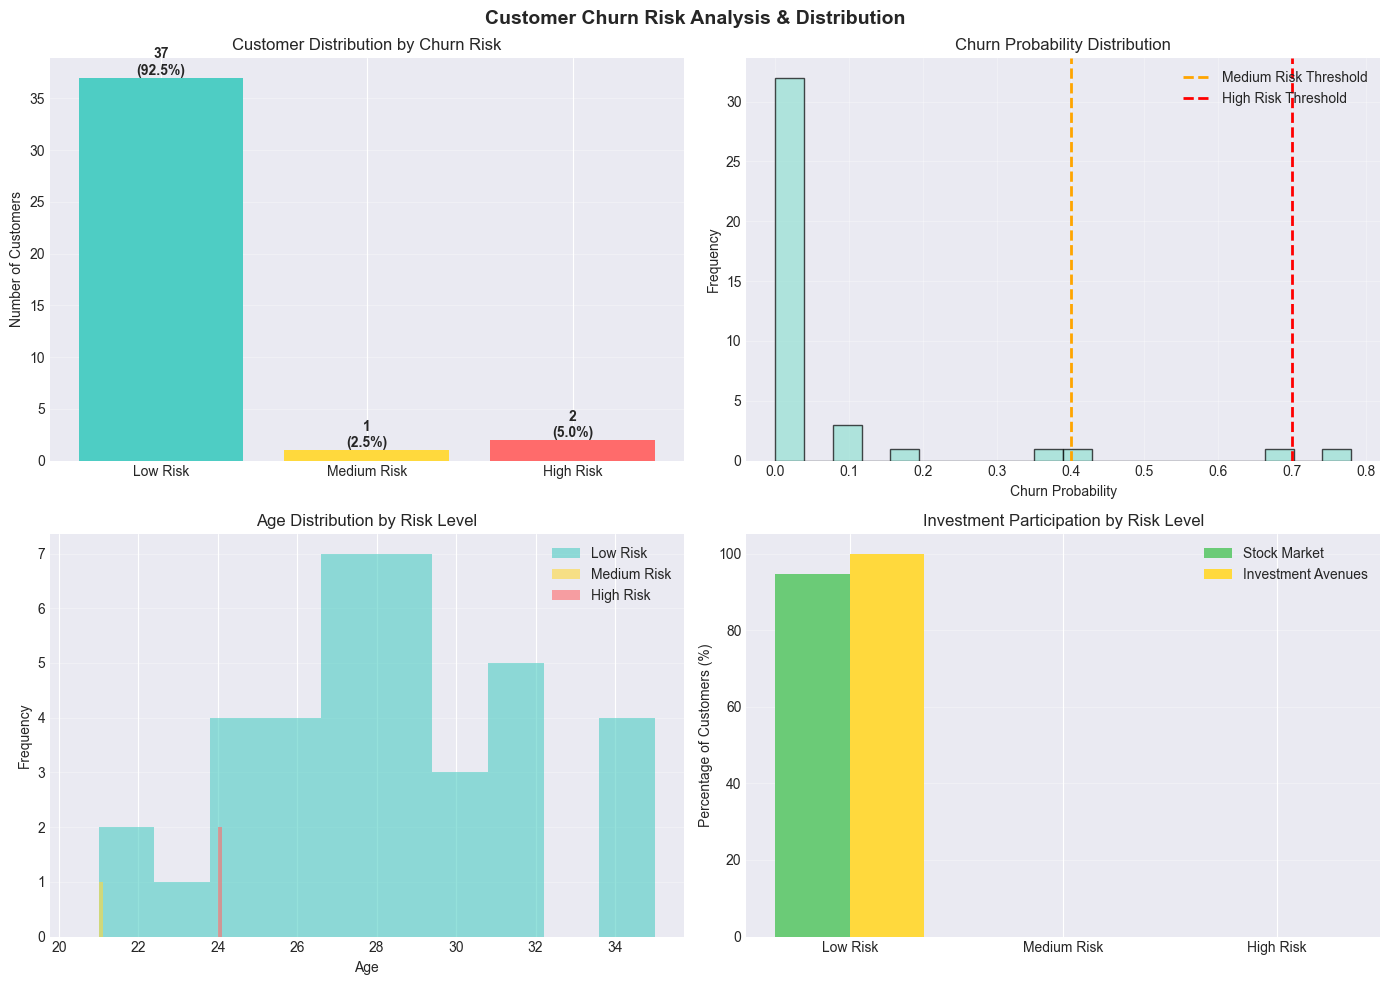

✓ Risk analysis visualization completed


In [19]:
# Churn Risk Distribution Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Churn Risk Analysis & Distribution', fontsize=14, fontweight='bold')

# 1. Customer Distribution by Risk Level
ax1 = axes[0, 0]
risk_counts = [len(low_risk), len(medium_risk), len(high_risk)]
risk_labels = ['Low Risk', 'Medium Risk', 'High Risk']
colors_risk = ['#4ECDC4', '#FFD93D', '#FF6B6B']
bars = ax1.bar(risk_labels, risk_counts, color=colors_risk)
ax1.set_ylabel('Number of Customers')
ax1.set_title('Customer Distribution by Churn Risk')
for bar, val in zip(bars, risk_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(val)}\n({val/len(df_model)*100:.1f}%)', 
            ha='center', va='bottom', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Churn Probability Distribution
ax2 = axes[0, 1]
ax2.hist(df_model['churn_probability'], bins=20, color='#95E1D3', edgecolor='black', alpha=0.7)
ax2.axvline(0.4, color='orange', linestyle='--', linewidth=2, label='Medium Risk Threshold')
ax2.axvline(0.7, color='red', linestyle='--', linewidth=2, label='High Risk Threshold')
ax2.set_xlabel('Churn Probability')
ax2.set_ylabel('Frequency')
ax2.set_title('Churn Probability Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Age Distribution by Risk Level
ax3 = axes[1, 0]
if len(low_risk) > 0:
    ax3.hist(low_risk['age'], bins=10, alpha=0.6, label='Low Risk', color='#4ECDC4')
if len(medium_risk) > 0:
    ax3.hist(medium_risk['age'], bins=10, alpha=0.6, label='Medium Risk', color='#FFD93D')
if len(high_risk) > 0:
    ax3.hist(high_risk['age'], bins=10, alpha=0.6, label='High Risk', color='#FF6B6B')
ax3.set_xlabel('Age')
ax3.set_ylabel('Frequency')
ax3.set_title('Age Distribution by Risk Level')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Investment Behavior Comparison
ax4 = axes[1, 1]
risk_groups = ['Low Risk', 'Medium Risk', 'High Risk']
stock_inv_pct = [
    low_risk['Stock_Marktet'].mean()*100 if len(low_risk) > 0 else 0,
    medium_risk['Stock_Marktet'].mean()*100 if len(medium_risk) > 0 else 0,
    high_risk['Stock_Marktet'].mean()*100 if len(high_risk) > 0 else 0
]
avenues_inv_pct = [
    low_risk['Investment_Avenues'].mean()*100 if len(low_risk) > 0 else 0,
    medium_risk['Investment_Avenues'].mean()*100 if len(medium_risk) > 0 else 0,
    high_risk['Investment_Avenues'].mean()*100 if len(high_risk) > 0 else 0
]

x = np.arange(len(risk_groups))
width = 0.35
ax4.bar(x - width/2, stock_inv_pct, width, label='Stock Market', color='#6BCB77')
ax4.bar(x + width/2, avenues_inv_pct, width, label='Investment Avenues', color='#FFD93D')
ax4.set_ylabel('Percentage of Customers (%)')
ax4.set_title('Investment Participation by Risk Level')
ax4.set_xticks(x)
ax4.set_xticklabels(risk_groups)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("✓ Risk analysis visualization completed")

In [20]:
# Export Results for Further Analysis
print("\nExporting customer segmentation for operational use...")

# Create export dataframe
export_df = df_model[[
    'gender', 'age', 'Stock_Marktet', 'Investment_Avenues', 
    'engagement_score', 'investment_count',
    'predicted_churn_risk', 'churn_probability'
]].copy()

export_df['risk_segment'] = export_df['churn_probability'].apply(
    lambda x: 'HIGH RISK' if x >= 0.7 else ('MEDIUM RISK' if x >= 0.4 else 'LOW RISK')
)

print(f"\n✓ Export Summary:")
print(f"   • Total Records: {len(export_df)}")
print(f"   • High Risk: {(export_df['risk_segment'] == 'HIGH RISK').sum()}")
print(f"   • Medium Risk: {(export_df['risk_segment'] == 'MEDIUM RISK').sum()}")
print(f"   • Low Risk: {(export_df['risk_segment'] == 'LOW RISK').sum()}")

print(f"\n📊 Sample High-Risk Customers for Targeted Action:")
print(export_df[export_df['risk_segment'] == 'HIGH RISK'].head(10)[[
    'age', 'Stock_Marktet', 'Investment_Avenues', 'churn_probability', 'risk_segment'
]])


Exporting customer segmentation for operational use...

✓ Export Summary:
   • Total Records: 40
   • High Risk: 2
   • Medium Risk: 1
   • Low Risk: 37

📊 Sample High-Risk Customers for Targeted Action:
   age  Stock_Marktet  Investment_Avenues  churn_probability risk_segment
4   24          False               False               0.70    HIGH RISK
5   24          False               False               0.78    HIGH RISK
